# Step 5 — Whole-recording spike detection, manual filtering & summary CSV

Applies the **same standard as Step 1–3**, but to the **entire `.mat` recording** instead of only the opto pre/during/post peri-stimulus windows.

**Workflow**
1. **Spike detection (whole recording).** Batch-process every `.mat` file with the same adaptive-threshold detector used in Step 1 (`process_spikes`, via the helper `plot_entire_single_file`). One CSV per recording, full timeline.
2. **Manual spike filtering.** Inspect spike-amplitude histograms (same as Step 3 Block 1), pick a `[min_amp, max_amp]` cut-off, then zero out spikes outside that range and recompute the spike rate (same as Step 3 Block 2). An optional scrollable inspector lets you verify the cut-off across the whole trace.
3. **Save summary CSV.** Each filtered recording is written as a summary CSV containing `Time (s)`, `Wingbeat Frequency` (WBF), `Raw EMG`, `Spike Count`, `Spike Amplitude`, `Opto Stimulus` (plus `Wing Beat Amplitude`, `X Position`, `Spike Rate`, `hutchens` for compatibility with Step 2/4).

> Run the blocks top-to-bottom. All spike-detection / spike-rate / opto-parsing / plot-style logic is **reused** from `spiracle_helper_functions.py` — nothing is re-implemented.

---

# 第五步 —— 全记录锋电位检测、人工筛选与汇总 CSV

采用**与第一至三步相同的标准**，但作用于**整段 `.mat` 记录**，而非仅刺激周围的 pre/during/post 窗口。

**流程**
1. **锋电位检测（全记录）。** 用与第一步相同的自适应阈值检测器（`process_spikes`，经辅助函数 `plot_entire_single_file`）批量处理每个 `.mat` 文件。每段记录一个 CSV，覆盖完整时间轴。
2. **人工锋电位筛选。** 查看锋电位幅度直方图（同第三步 Block 1），选取 `[min_amp, max_amp]` 阈值，将范围外的锋电位置 0 并重新计算发放率（同第三步 Block 2）。可选的可滚动检查器可在整条曲线上核对阈值。
3. **保存汇总 CSV。** 每段筛选后的记录写为汇总 CSV，含 `Time (s)`、`Wingbeat Frequency`(WBF)、`Raw EMG`、`Spike Count`、`Spike Amplitude`、`Opto Stimulus`（外加 `Wing Beat Amplitude`、`X Position`、`Spike Rate`、`hutchens` 以兼容第二/四步）。

> 请自上而下运行各 Block。所有锋电位检测／发放率／光遗传解析／绘图样式逻辑均**复用**自 `spiracle_helper_functions.py`——没有任何重复实现。

## Block 1 — Spike detection over the entire recording

Reuses `plot_entire_single_file()` from the helper module, which runs the identical pipeline as Step 1 (`load_and_reshape_data` → `extract_traces` → `smooth_data` → `transform_opto_stimulus` → `process_spikes`) **without** peri-stimulus bout extraction, and writes `<recording>_entire.csv` (+ an overview PNG).

Edit `input_directory` / `output_directory`, then run.

**Block 1 —— 对整段记录做锋电位检测**

复用辅助模块中的 `plot_entire_single_file()`，它运行与第一步完全相同的流程（`load_and_reshape_data` → `extract_traces` → `smooth_data` → `transform_opto_stimulus` → `process_spikes`），但**不做**刺激周围片段提取，写出 `<记录名>_entire.csv`（外加一张总览 PNG）。修改 `input_directory` / `output_directory` 后运行即可。

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm

# Reuse all shared helpers (load / extract / spike-detection / opto / plot-style)
%run '/Users/camellyc/Library/Mobile Documents/com~apple~CloudDocs/学习/Lab/Tuthill Lab/Codes/Flight_Arena_Analysis/spiracle_helper_functions.py'
set_plot_style()

# ====== EDIT THESE ======
input_directory  = '/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2026_0510_Fly4'
output_directory = '/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2026_0510_Fly4/output_csv_entire'
sampling_rate       = 20000
make_overview_plots = True   # save a 4-panel WBF / Amp / SpikeRate / Opto PNG per recording
# ========================

os.makedirs(output_directory, exist_ok=True)

mat_files = [f for f in os.listdir(input_directory) if f.endswith('.mat')]
print(f"Found {len(mat_files)} .mat files to process")

entire_csvs = []
for file_name in tqdm(mat_files, desc="Detecting spikes (whole recording)"):
    file_path = os.path.join(input_directory, file_name)
    try:
        out_csv = plot_entire_single_file(
            file_path, output_directory, fs=sampling_rate, make_plot=make_overview_plots
        )
        if out_csv:
            entire_csvs.append(out_csv)
    except Exception as e:
        print(f"Error processing {file_name}: {e}")

print(f"\nDone. Wrote {len(entire_csvs)} whole-recording CSV(s) to:\n  {output_directory}")

Found 1 .mat files to process


Detecting spikes (whole recording):   0%|          | 0/1 [00:00<?, ?it/s]


Processing ENTIRE file: /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2025_1226_Fly3/2025_1226_155640_SpMN4_ChR_EMG_SpMN4_ChR_5d_F_Fly3_Trial1_3000msx3_thorax.mat
Loaded data shape: (9, 5392000)
Number of blocks detected: 6
Lengths of detected blocks (in seconds): [3.0, 2.9969, 2.9969, 2.9969, 2.9969, 2.9969]


Detecting Spikes: 100%|██████████| 5391900/5391900 [00:01<00:00, 4858447.74it/s]


Saved entire-file CSV: /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2025_1226_Fly3/output_csv_entire/2025_1226_155640_SpMN4_ChR_EMG_SpMN4_ChR_5d_F_Fly3_Trial1_3000msx3_thorax_entire.csv


Detecting spikes (whole recording): 100%|██████████| 1/1 [03:39<00:00, 219.57s/it]

Saved overview plot: /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2025_1226_Fly3/output_csv_entire/2025_1226_155640_SpMN4_ChR_EMG_SpMN4_ChR_5d_F_Fly3_Trial1_3000msx3_thorax_entire_overview.png

Done. Wrote 1 whole-recording CSV(s) to:
  /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2025_1226_Fly3/output_csv_entire


## Block 2 — Manual spike filtering (step 1): inspect amplitude histograms

Same idea as **Step 3 Block 1**, but on the whole-recording CSVs (`*_entire.csv`). Look at the spike-amplitude distribution and choose a `[min_amp, max_amp]` cut-off (in Volts) that isolates the DLMn spikes. You will apply that cut-off in Block 3.

> Run Block 1 first (it defines `output_directory` and `sampling_rate`).

**Block 2 —— 人工锋电位筛选（第 1 步）：查看幅度直方图**

思路同**第三步 Block 1**，但作用于全记录 CSV（`*_entire.csv`）。查看锋电位幅度分布，选择能分离出 DLMn 锋电位的 `[min_amp, max_amp]` 阈值（单位伏特），将在 Block 3 中应用。

> 请先运行 Block 1（它定义了 `output_directory` 与 `sampling_rate`）。

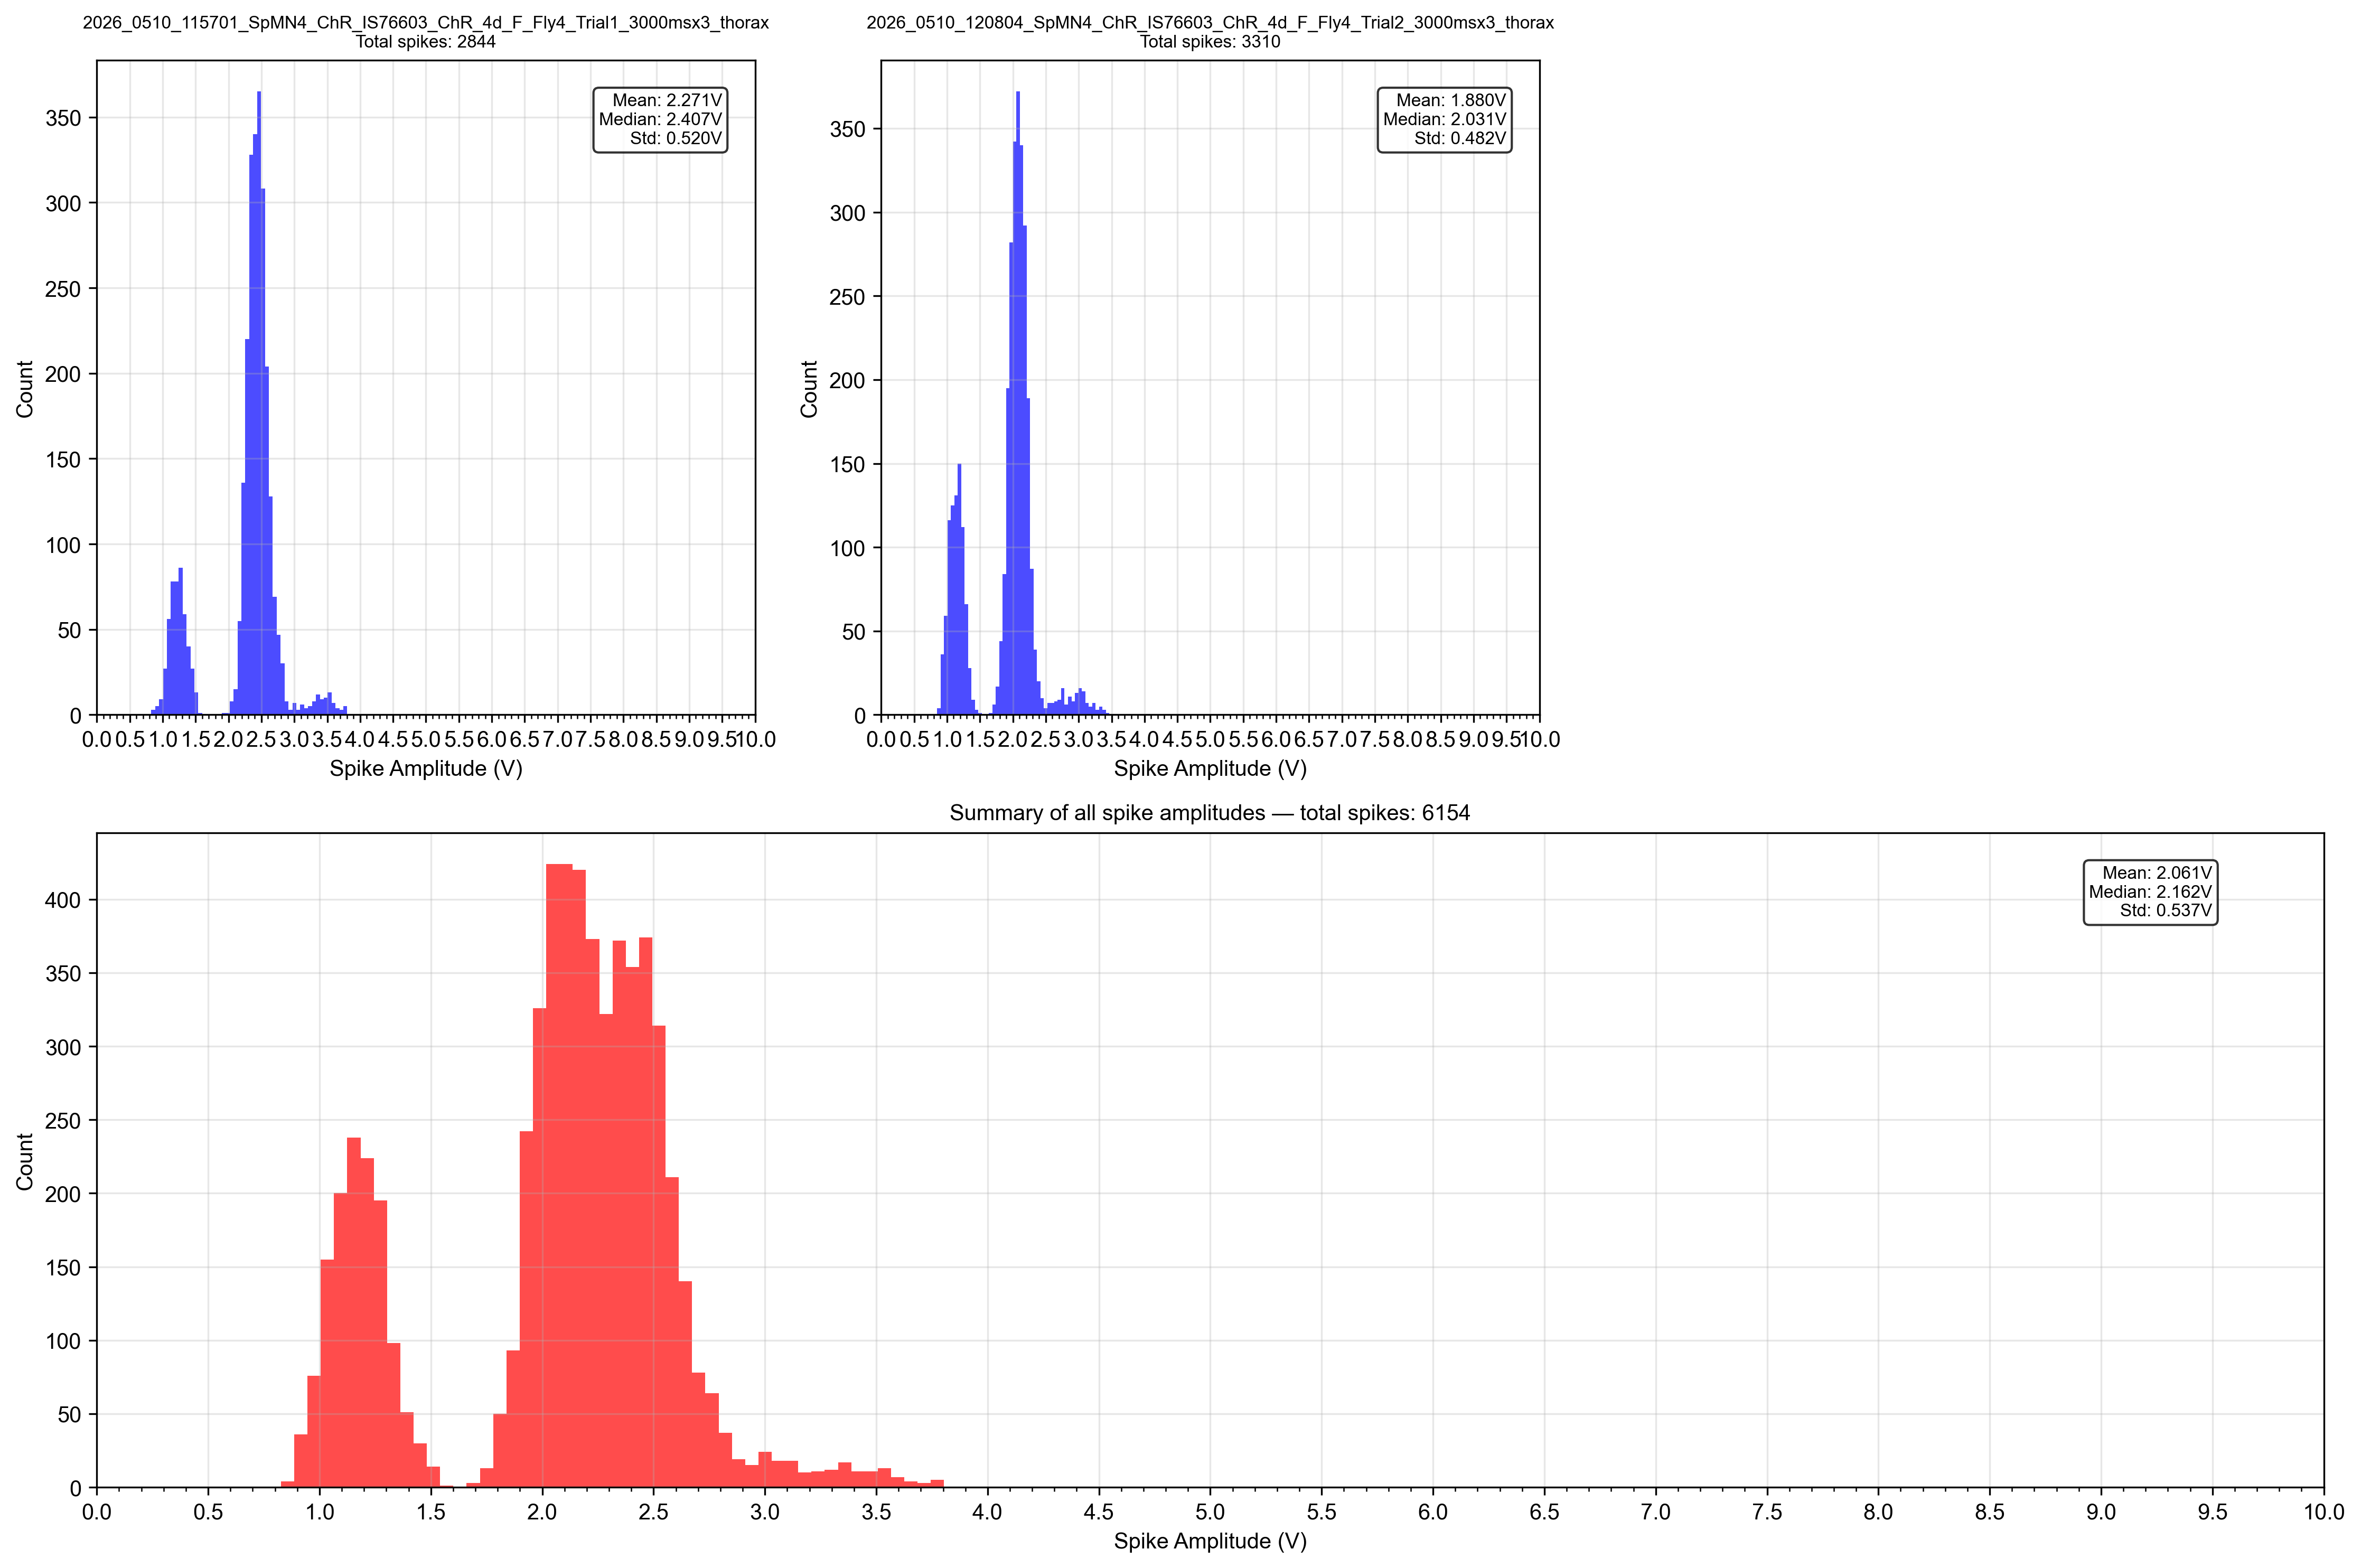

In [6]:
# Spike-amplitude histograms across all whole-recording CSVs in output_directory.
from matplotlib.ticker import MultipleLocator

try:
    from natsort import natsorted
except Exception:
    natsorted = sorted  # graceful fallback if natsort is unavailable

def plot_entire_amplitude_histograms(folder_path, bins=50, xmax=10):
    """Histogram of detected-spike amplitudes for every *_entire.csv in a folder,
    plus a pooled summary histogram. Mirrors Step 3 Block 1 but for whole recordings."""
    csv_files = natsorted([
        os.path.join(folder_path, f) for f in os.listdir(folder_path)
        if f.endswith('_entire.csv')
    ])
    if not csv_files:
        print("No *_entire.csv files found in", folder_path)
        return

    all_amps = []
    n = len(csv_files)
    n_cols = 3
    n_rows = (n + n_cols - 1) // n_cols
    fig = plt.figure(figsize=(15, 5 * (n_rows + 1)))
    gs = plt.GridSpec(n_rows + 1, n_cols, figure=fig)

    for idx, path in enumerate(csv_files):
        ax = fig.add_subplot(gs[idx // n_cols, idx % n_cols])
        df = pd.read_csv(path)
        amps = df['Spike Amplitude'][df['Spike Count'] == 1]
        all_amps.extend(amps)
        ax.hist(amps, bins=bins, color='blue', alpha=0.7)
        ax.set_xlim(0, xmax)
        ax.xaxis.set_major_locator(MultipleLocator(0.5))  # labeled ticks every 0.5
        ax.xaxis.set_minor_locator(MultipleLocator(0.1))  # tick marks every 0.1
        ax.set_xlabel('Spike Amplitude (V)')
        ax.set_ylabel('Count')
        if len(amps) > 0:
            stats_text = f"Mean: {np.mean(amps):.3f}V\nMedian: {np.median(amps):.3f}V\nStd: {np.std(amps):.3f}V"
        else:
            stats_text = "no spikes"
        ax.set_title(f"{os.path.basename(path).replace('_entire.csv','')}\nTotal spikes: {len(amps)}", fontsize=8)
        ax.text(0.95, 0.95, stats_text, transform=ax.transAxes,
                va='top', ha='right', fontsize=8,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        ax.grid(True, alpha=0.3)

    ax_sum = fig.add_subplot(gs[-1, :])
    ax_sum.hist(all_amps, bins=bins, color='red', alpha=0.7)
    ax_sum.set_xlim(0, xmax)
    ax_sum.xaxis.set_major_locator(MultipleLocator(0.5))  # labeled ticks every 0.5
    ax_sum.xaxis.set_minor_locator(MultipleLocator(0.1))  # tick marks every 0.1
    ax_sum.set_xlabel('Spike Amplitude (V)')
    ax_sum.set_ylabel('Count')
    if len(all_amps) > 0:
        s = f"Mean: {np.mean(all_amps):.3f}V\nMedian: {np.median(all_amps):.3f}V\nStd: {np.std(all_amps):.3f}V"
        ax_sum.text(0.95, 0.95, s, transform=ax_sum.transAxes, va='top', ha='right',
                    fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    ax_sum.set_title(f"Summary of all spike amplitudes — total spikes: {len(all_amps)}", fontsize=10)
    ax_sum.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_entire_amplitude_histograms(output_directory, bins=50, xmax=10)

**(Optional) Interactive cut-off inspector.** A scrollable widget for one whole recording: it overlays detected spikes on the raw EMG and colors them green (kept) or gray (rejected) for a candidate `[min_amp, max_amp]`, with a draggable time window and editable amplitude bounds, so you can verify the cut-off before committing. Requires `ipywidgets`; skip if you prefer the histogram-only workflow.

**（可选）交互式阈值检查器。** 针对单段记录的可滚动小部件：在原始 EMG 上叠加检测到的锋电位，并按候选 `[min_amp, max_amp]` 将其着为绿色（保留）或灰色（剔除），配有可拖动的时间窗与可编辑的幅度上下限，便于在正式应用前核对阈值。需要 `ipywidgets`；若偏好纯直方图流程可跳过。

In [7]:
# OPTIONAL interactive inspector: scroll through one whole recording, overlay detected
# spikes, and preview a candidate [min_amp, max_amp] cut-off (green = kept, gray = rejected).
# Requires ipywidgets. Skip if you prefer the histogram-only workflow above.
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
try:
    import ipywidgets as widgets
    from IPython.display import display
    _HAVE_WIDGETS = True
except Exception as e:
    _HAVE_WIDGETS = False
    print("ipywidgets not available — skipping interactive inspector:", e)

_csvs = sorted([os.path.join(output_directory, f) for f in os.listdir(output_directory)
                if f.endswith('_entire.csv')])
file_index = 0   # <-- change to inspect a different recording

if _HAVE_WIDGETS and _csvs:
    insp_path = _csvs[file_index]
    print("Inspecting:", os.path.basename(insp_path))
    _df = pd.read_csv(insp_path)
    _t   = _df['Time (s)'].values
    _emg = _df['Raw EMG'].values
    _sc  = _df['Spike Count'].values.astype(bool)
    _amp = _df['Spike Amplitude'].values
    _opto = (_df['Opto Stimulus'].values > 0).astype(int)
    total_dur = _t[-1] if len(_t) else 0.0

    def _spans(time, opto):
        d = np.diff(opto, prepend=0, append=0)
        s = np.where(d == 1)[0]; e = np.where(d == -1)[0]
        return [(time[a], time[min(b, len(time) - 1)]) for a, b in zip(s, e)]
    _opto_spans = _spans(_t, _opto)

    def _downsample(x, y, max_pts=200000):
        if len(x) <= max_pts:
            return x, y
        step = len(x) // max_pts
        return x[::step], y[::step]

    win = widgets.FloatRangeSlider(value=[0, min(total_dur, 30)], min=0, max=total_dur, step=0.1,
                                   description='Window (s):', continuous_update=False,
                                   readout_format='.2f', layout=widgets.Layout(width='70%'))
    amp_lo = widgets.FloatText(value=1.0, description='min_amp')
    amp_hi = widgets.FloatText(value=6.0, description='max_amp')
    out = widgets.Output()
    _state = {'fig': None}

    def draw(*_):
        with out:
            out.clear_output(wait=True)
            if _state['fig'] is not None:
                plt.close(_state['fig'])
            t0, t1 = win.value
            i0, i1 = int(t0 * sampling_rate), int(t1 * sampling_rate)
            i1 = min(i1, len(_t))
            fig, ax = plt.subplots(figsize=(14, 4))
            xx, yy = _downsample(_t[i0:i1], _emg[i0:i1])
            ax.plot(xx, yy, color='black', linewidth=0.5)
            sp = _sc[i0:i1]
            sp_t = _t[i0:i1][sp]; sp_v = _emg[i0:i1][sp]; sp_a = _amp[i0:i1][sp]
            keep = (sp_a >= amp_lo.value) & (sp_a <= amp_hi.value)
            ax.scatter(sp_t[keep],  sp_v[keep],  color='green', s=18, label='kept')
            ax.scatter(sp_t[~keep], sp_v[~keep], color='gray',  s=18, label='rejected')
            for a, b in _opto_spans:
                if b >= t0 and a <= t1:
                    ax.axvspan(max(a, t0), min(b, t1), color='lightgreen', alpha=0.3)
            ax.set_xlim(t0, t1); ax.set_xlabel('Time (s)'); ax.set_ylabel('Raw EMG (V)')
            ax.set_title(f"{os.path.basename(insp_path)}  |  amp in [{amp_lo.value}, {amp_hi.value}] V")
            ax.legend(loc='upper right')
            plt.tight_layout(); _state['fig'] = fig; plt.show()

    for w in (win, amp_lo, amp_hi):
        w.observe(draw, names='value')
    display(widgets.VBox([widgets.HBox([amp_lo, amp_hi]), win, out]))
    draw()

Inspecting: 2026_0510_115701_SpMN4_ChR_IS76603_ChR_4d_F_Fly4_Trial1_3000msx3_thorax_entire.csv


## Block 3 — Manual spike filtering (step 2) + save summary CSV

Same logic as **Step 3 Block 2** (`process_spikefiltered_csv`), adapted to whole recordings (no per-stimulus subfolders). Set `min_amp` / `max_amp` from your histogram inspection. Spikes with amplitude outside the range have their `Spike Count` set to 0, `Spike Rate` is recomputed with the standard Gaussian filter (`calculate_spike_rate`, target 7 Hz), and each recording is saved as a summary CSV.

**Summary CSV columns:** `Time (s)`, `Wingbeat Frequency`, `Wing Beat Amplitude`, `X Position`, `Raw EMG`, `Spike Rate`, `Spike Count`, `Spike Amplitude`, `Opto Stimulus`, `hutchens`.

**Block 3 —— 人工锋电位筛选（第 2 步）+ 保存汇总 CSV**

逻辑同**第三步 Block 2**（`process_spikefiltered_csv`），改为针对整段记录（不分刺激子文件夹）。根据直方图检查结果设置 `min_amp` / `max_amp`。范围外的锋电位 `Spike Count` 置 0，用标准高斯滤波器（`calculate_spike_rate`，目标 7 Hz）重新计算 `Spike Rate`，每段记录保存为汇总 CSV。

**汇总 CSV 列：** `Time (s)`、`Wingbeat Frequency`、`Wing Beat Amplitude`、`X Position`、`Raw EMG`、`Spike Rate`、`Spike Count`、`Spike Amplitude`、`Opto Stimulus`、`hutchens`。

In [8]:
import os
import glob
import numpy as np
import pandas as pd
from tqdm import tqdm

# calculate_spike_rate lives in the helper module
%run '/Users/camellyc/Library/Mobile Documents/com~apple~CloudDocs/学习/Lab/Tuthill Lab/Codes/Flight_Arena_Analysis/spiracle_helper_functions.py'

# ====== set from your histogram inspection (Block 2) ======
min_amp = 1.6
max_amp = 10
# ==========================================================

filtered_dir = os.path.join(output_directory, 'spikefiltered_entire')
os.makedirs(filtered_dir, exist_ok=True)

def process_entire_spikefiltered_csv(file_path, output_dir, amp_range, sampling_rate=20000):
    """Whole-recording analogue of Step 3's process_spikefiltered_csv:
    zero out spikes whose amplitude is outside amp_range, recompute Spike Rate,
    and save a summary CSV. Returns the output path."""
    df = pd.read_csv(file_path)
    mask = (df['Spike Count'] == 1)
    outside = (df['Spike Amplitude'] < amp_range[0]) | (df['Spike Amplitude'] > amp_range[1])
    df.loc[mask & outside, 'Spike Count'] = 0
    df['Spike Rate'] = calculate_spike_rate(df['Spike Count'].values, sampling_rate)
    stem = os.path.splitext(os.path.basename(file_path))[0]
    out_path = os.path.join(output_dir, f"{stem}_spikefiltered.csv")
    df.to_csv(out_path, index=False)
    return out_path

# Re-glob so this block works even if Block 1 was run in a previous session
entire_csvs = sorted(glob.glob(os.path.join(output_directory, '*_entire.csv')))
print(f"Filtering {len(entire_csvs)} recording(s) with amplitude range [{min_amp}, {max_amp}] V")

filtered_csvs = []
for csv_path in tqdm(entire_csvs, desc="Amplitude-filtering"):
    filtered_csvs.append(
        process_entire_spikefiltered_csv(csv_path, filtered_dir, (min_amp, max_amp), sampling_rate)
    )

print(f"\nSaved {len(filtered_csvs)} summary CSV(s) to:\n  {filtered_dir}")

Filtering 2 recording(s) with amplitude range [1.6, 10] V


Amplitude-filtering: 100%|██████████| 2/2 [00:52<00:00, 26.15s/it]


Saved 2 summary CSV(s) to:
  /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2026_0510_Fly4/output_csv_entire/spikefiltered_entire


**Whole-recording QC figure.** `plot_entire_recording` draws a 3-panel overview of each filtered recording — (1) WBF + spike rate, (2) raw EMG with detected spikes, (3) spike raster — with all opto blocks shaded across the full timeline, saved as an editable SVG. Run on every `*_spikefiltered.csv`.

**全记录质量检查图。** `plot_entire_recording` 为每段筛选后的记录绘制三联总览图——(1) WBF + 发放率、(2) 带检测锋电位的原始 EMG、(3) 锋电位栅格——并在完整时间轴上对所有光遗传区块加阴影，保存为可编辑 SVG。对每个 `*_spikefiltered.csv` 运行。

Saved /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2026_0510_Fly4/output_csv_entire/spikefiltered_entire/output_plots/2026_0510_115701_SpMN4_ChR_IS76603_ChR_4d_F_Fly4_Trial1_3000msx3_thorax_entire_spikefiltered_overview.svg


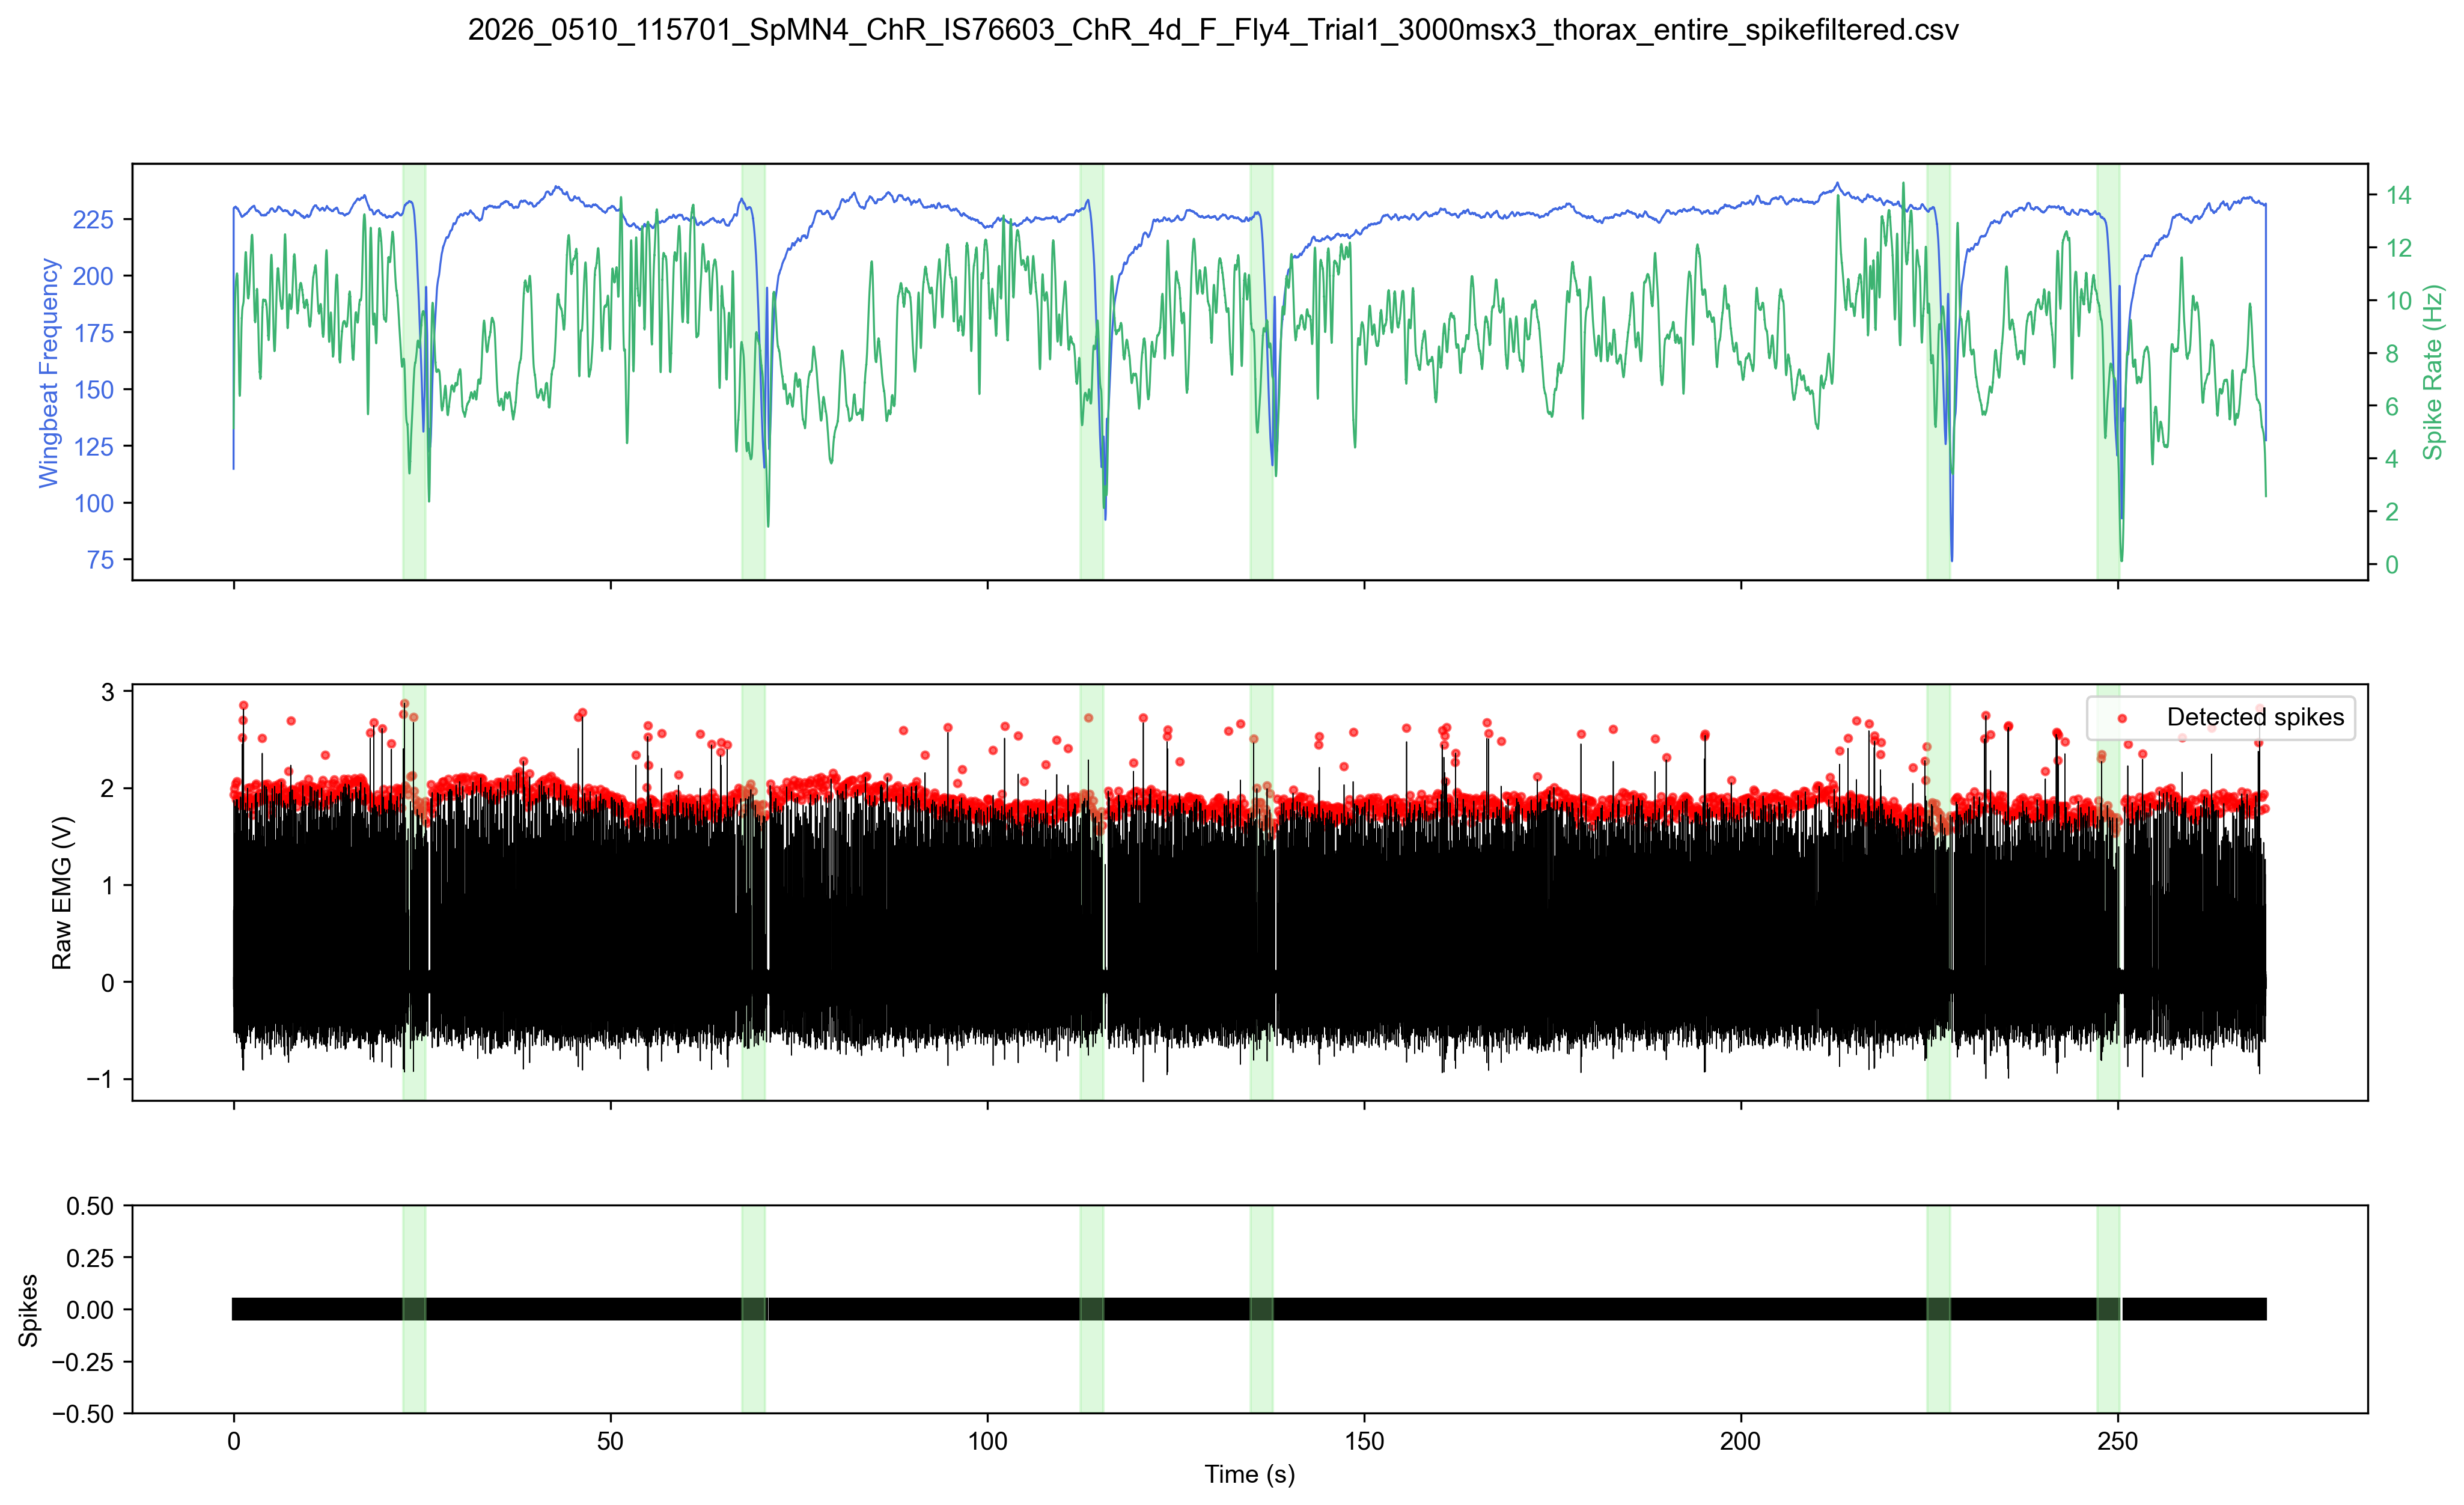

Saved /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2026_0510_Fly4/output_csv_entire/spikefiltered_entire/output_plots/2026_0510_120804_SpMN4_ChR_IS76603_ChR_4d_F_Fly4_Trial2_3000msx3_thorax_entire_spikefiltered_overview.svg


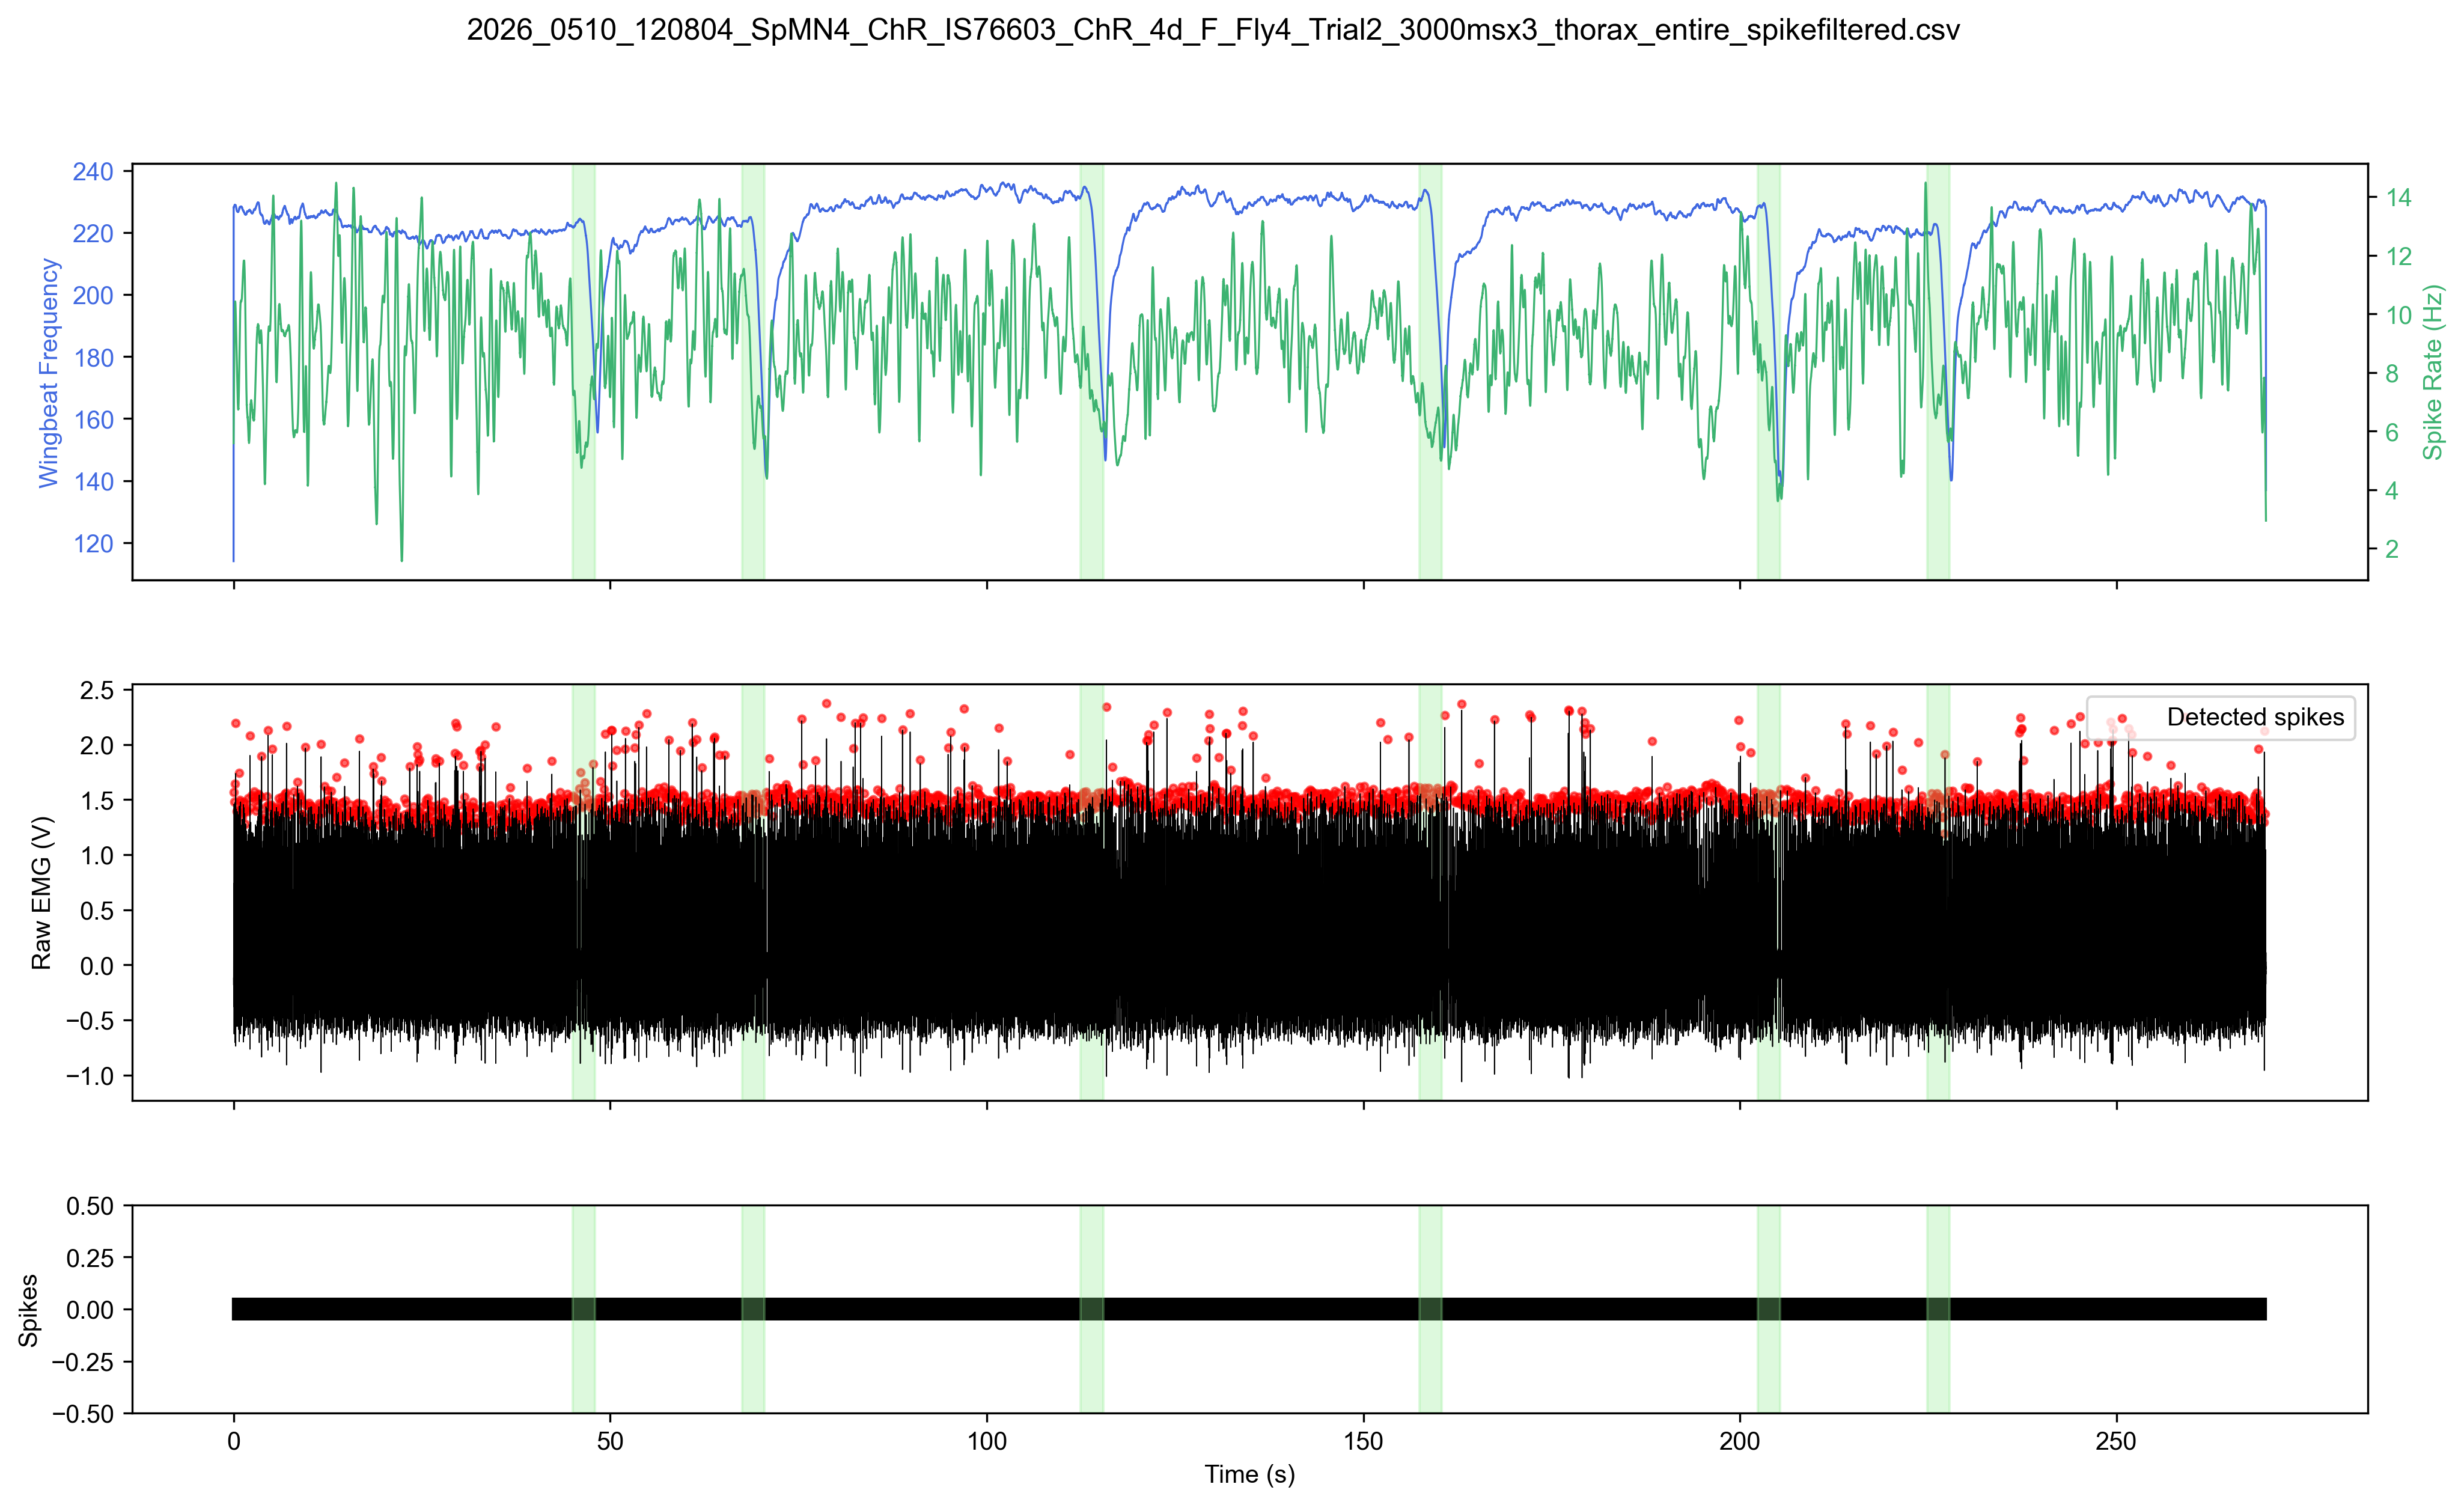

In [9]:
# Quality-check plot of an entire filtered recording: WBF + spike rate, raw EMG + detected
# spikes, and a spike raster, with opto blocks shaded across the whole timeline.
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def _opto_spans(time, opto):
    opto = (np.asarray(opto) > 0).astype(int)
    d = np.diff(opto, prepend=0, append=0)
    s = np.where(d == 1)[0]; e = np.where(d == -1)[0]
    return [(time[a], time[min(b, len(time) - 1)]) for a, b in zip(s, e)]

def _downsample(x, y, max_pts=300000):
    if len(x) <= max_pts:
        return x, y
    step = len(x) // max_pts
    return x[::step], y[::step]

def plot_entire_recording(csv_file, output_dir=None, stim_color='lightgreen', max_pts=300000):
    """Whole-recording QC figure (no peri-stimulus baseline). Saves an editable SVG if output_dir given."""
    df = pd.read_csv(csv_file)
    t = df['Time (s)'].values
    spans = _opto_spans(t, df['Opto Stimulus'].values)

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(16, 9), height_ratios=[2, 2, 1], sharex=True)
    plt.subplots_adjust(hspace=0.3)

    # Panel 1: WBF (left) + spike rate (right)
    xx, yy = _downsample(t, df['Wingbeat Frequency'].values, max_pts)
    ax1.plot(xx, yy, color='royalblue', linewidth=0.8, label='WBF')
    ax1.set_ylabel('Wingbeat Frequency', color='royalblue')
    ax1.tick_params(axis='y', labelcolor='royalblue')
    ax1r = ax1.twinx()
    xr, yr = _downsample(t, df['Spike Rate'].values, max_pts)
    ax1r.plot(xr, yr, color='mediumseagreen', linewidth=0.8, label='Spike Rate')
    ax1r.set_ylabel('Spike Rate (Hz)', color='mediumseagreen')
    ax1r.tick_params(axis='y', labelcolor='mediumseagreen')

    # Panel 2: raw EMG + detected spikes
    xe, ye = _downsample(t, df['Raw EMG'].values, max_pts)
    ax2.plot(xe, ye, color='black', linewidth=0.4)
    sc = df['Spike Count'].values == 1
    ax2.scatter(t[sc], df['Raw EMG'].values[sc], color='red', s=8, alpha=0.6, label='Detected spikes')
    ax2.set_ylabel('Raw EMG (V)')
    ax2.legend(loc='upper right')

    # Panel 3: raster
    ax3.scatter(t[sc], np.zeros(int(sc.sum())), marker='|', color='black', s=80)
    ax3.set_ylabel('Spikes'); ax3.set_xlabel('Time (s)'); ax3.set_ylim(-0.5, 0.5)

    for ax in (ax1, ax2, ax3):
        for a, b in spans:
            ax.axvspan(a, b, color=stim_color, alpha=0.3)

    plt.suptitle(os.path.basename(csv_file), y=0.97)
    if output_dir:
        os.makedirs(output_dir, exist_ok=True)
        out = os.path.join(output_dir, os.path.splitext(os.path.basename(csv_file))[0] + '_overview.svg')
        plt.savefig(out, format='svg', bbox_inches='tight')
        print("Saved", out)
    plt.show()

# Plot every filtered recording (set output_dir=None to only display, not save)
plot_out_dir = os.path.join(filtered_dir, 'output_plots')
for csv_path in sorted(glob.glob(os.path.join(filtered_dir, '*_spikefiltered.csv'))):
    plot_entire_recording(csv_path, output_dir=plot_out_dir)

## Block 4 (optional) — Per-recording summary table

One row per recording with overall stats (duration, #opto blocks, total spikes, mean spike rate / WBF / WBA), plus a manual `keep` column — analogous to Step 3's `bout_quality_summary.csv`, but at the whole-recording level. Useful for deciding which recordings to include downstream.

**Block 4（可选）—— 逐记录汇总表**

每段记录一行，含整体统计（时长、光遗传区块数、锋电位总数、平均发放率／WBF／WBA），外加人工 `keep` 列——类似第三步的 `bout_quality_summary.csv`，但在整段记录层面。便于决定下游纳入哪些记录。

In [10]:
import os
import glob
import numpy as np
import pandas as pd

def _n_opto_blocks(opto):
    opto = (np.asarray(opto) > 0).astype(int)
    return int(np.sum(np.diff(opto, prepend=0) == 1))

rows = []
for csv_path in sorted(glob.glob(os.path.join(filtered_dir, '*_spikefiltered.csv'))):
    df = pd.read_csv(csv_path)
    t = df['Time (s)'].values
    dur = float(t[-1] - t[0]) if len(t) > 1 else 0.0
    opto_on = (df['Opto Stimulus'].values > 0)
    rows.append({
        'filename':        os.path.basename(csv_path),
        'duration_s':      round(dur, 2),
        'n_opto_blocks':   _n_opto_blocks(df['Opto Stimulus'].values),
        'opto_on_time_s':  round(float(opto_on.sum()) / sampling_rate, 3),
        'n_spikes_total':  int(df['Spike Count'].sum()),
        'mean_spike_rate': round(float(df['Spike Rate'].mean()), 3),
        'mean_WBF':        round(float(df['Wingbeat Frequency'].mean()), 2),
        'mean_WBA':        round(float(df['Wing Beat Amplitude'].mean()), 3),
        'keep':            '',   # fill in manually: 'Y' to keep, 'N' to exclude
    })

if rows:
    summary_df = pd.DataFrame(rows)
    out_path = os.path.join(filtered_dir, 'recording_quality_summary.csv')
    summary_df.to_csv(out_path, index=False)
    print(f"Saved per-recording summary ({len(summary_df)} recordings) -> {out_path}")
    display(summary_df)
else:
    print("No *_spikefiltered.csv files found in", filtered_dir)

Saved per-recording summary (2 recordings) -> /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2026_0510_Fly4/output_csv_entire/spikefiltered_entire/recording_quality_summary.csv


,filename,duration_s,n_opto_blocks,opto_on_time_s,n_spikes_total,mean_spike_rate,mean_WBF,mean_WBA,keep
0,2026_0510_115701_SpMN4_ChR_IS76603_ChR_4d_F_Fl...,269.65,6,17.985,2362,8.756,221.90,6.922,
1,2026_0510_120804_SpMN4_ChR_IS76603_ChR_4d_F_Fl...,269.85,6,17.985,2470,9.150,222.92,7.134,


## Block 5 — 1-second-bin spike rate vs WBF correlation (by opto epoch)

Bins each `*_spikefiltered.csv` into **1 s bins** and scatters **spike rate (spikes/s) vs Wingbeat Frequency**, split into three opto epochs:

- **normal** — opto-off baseline / inter-trial gaps (**grey**)
- **on** — opto-ON (**red**)
- **post** — the 3 one-second bins right after each stimulus offset (**blue**)

ON/POST bins are referenced to each stimulus **onset/offset**, with a small tolerance so a measured ~2.999 s stimulus counts as **3** ON bins (not 2). Spike rate is count-based (`spikes ÷ bin length`). Processes **all** CSVs in `corr_input_directory`: one scatter per CSV **and** a pooled scatter, plus a combined `binned_1s_spikerate_wbf.csv`.

**Block 5 —— 1 秒分箱的发放率对 WBF 相关性（按光遗传时期）**

将每个 `*_spikefiltered.csv` 切成 **1 秒箱**，绘制**发放率（spikes/s）对翅拍频率**的散点，按三个光遗传时期着色：**normal**——光关闭的基线／试次间隙（灰）；**on**——光开（红）；**post**——每次刺激结束后紧接的 3 个 1 秒箱（蓝）。ON/POST 箱以每次刺激的**起始/结束**为参照，并留有小容差，使测得约 2.999 秒的刺激计为 **3** 个 ON 箱（而非 2 个）。发放率基于计数（`锋电位数 ÷ 箱长`）。处理 `corr_input_directory` 中的**所有** CSV：每个 CSV 一张散点图，**外加**一张汇总散点图，以及合并的 `binned_1s_spikerate_wbf.csv`。

Found 1 spikefiltered CSV(s) in /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2025_1226_Fly3/output_csv_entire/spikefiltered_entire
Saved /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2025_1226_Fly3/output_csv_entire/spikefiltered_entire/correlation_plots/2025_1226_155640_SpMN4_ChR_EMG_SpMN4_ChR_5d_F_Fly3_Trial1_3000msx3_thorax_entire_spikefiltered_corr.svg


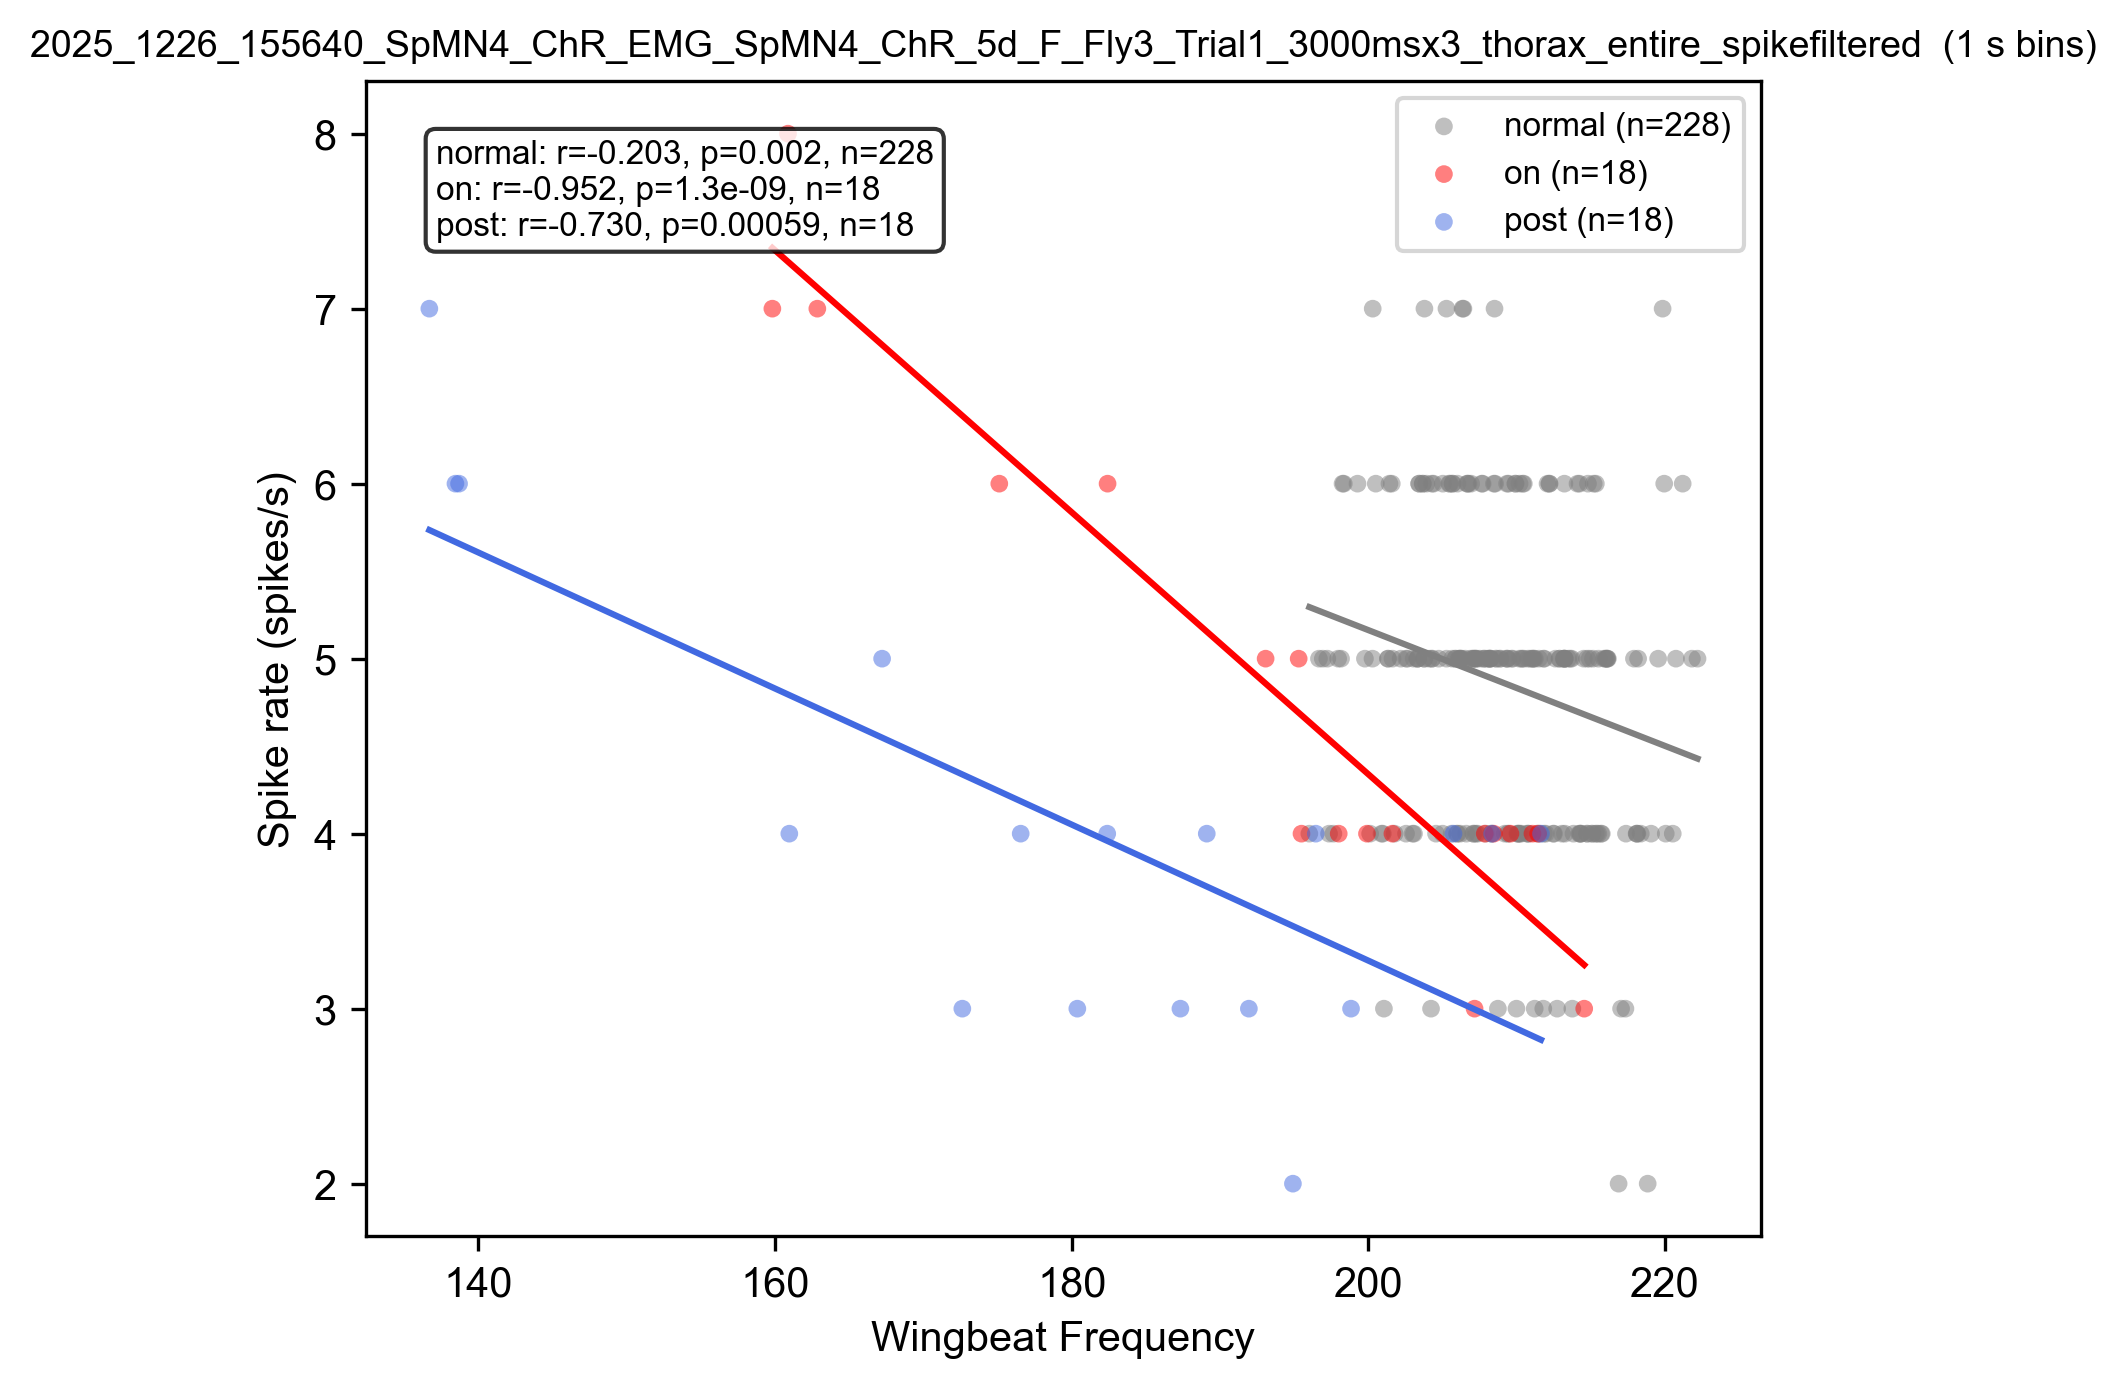

Saved combined binned data -> /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2025_1226_Fly3/output_csv_entire/spikefiltered_entire/binned_1s_spikerate_wbf.csv
Saved /Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2025_1226_Fly3/output_csv_entire/spikefiltered_entire/correlation_plots/ALL_pooled_corr.svg


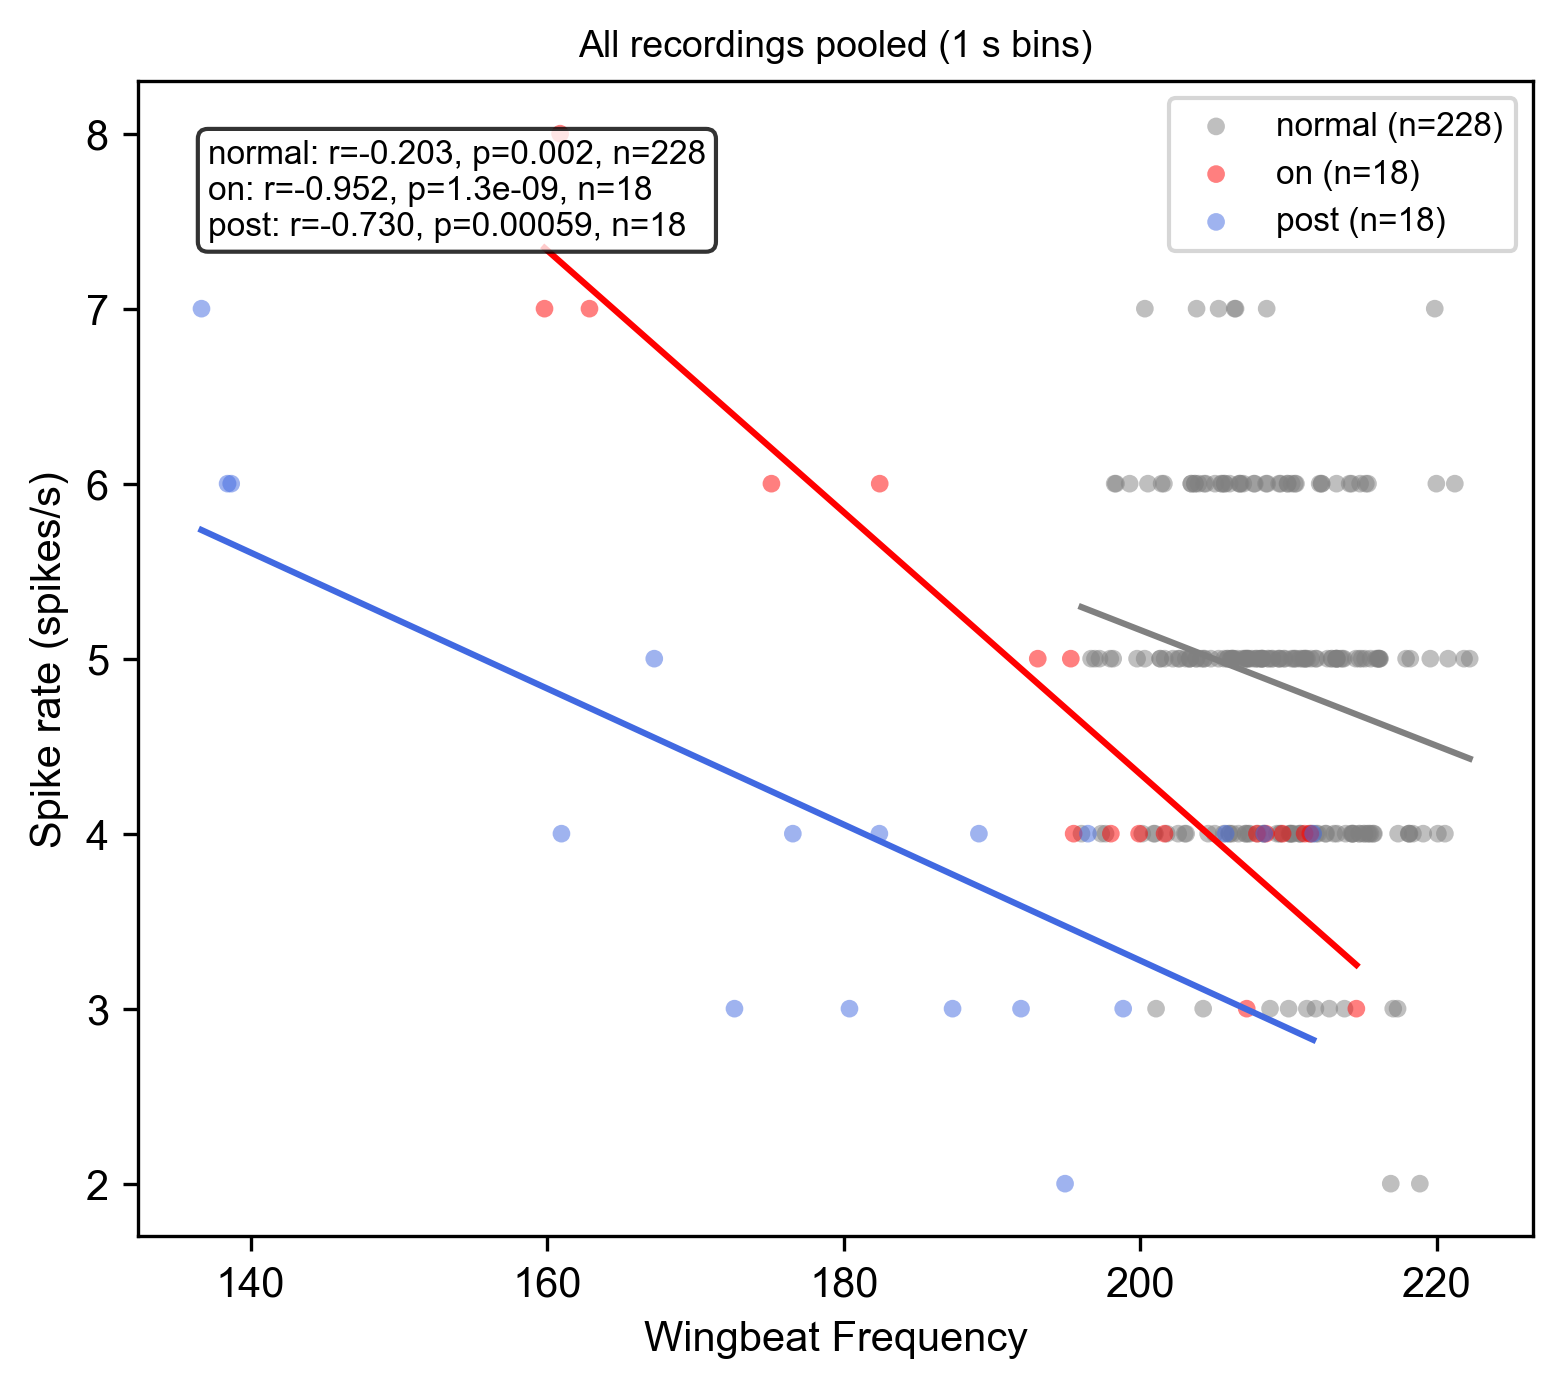

In [11]:
# Block 5 — 1 s-bin spike-rate vs WBF correlation, grouped by opto epoch
# Groups: normal (off, grey) | opto-ON (red) | post-opto = 3 bins after offset (blue)
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

%run '/Users/camellyc/Library/Mobile Documents/com~apple~CloudDocs/学习/Lab/Tuthill Lab/Codes/Flight_Arena_Analysis/spiracle_helper_functions.py'
set_plot_style()

# ====== EDIT THESE ======
corr_input_directory = '/Users/camellyc/Library/CloudStorage/GoogleDrive-yichen@tuthill.casa/.shortcut-targets-by-id/10pxdlRXtzFB-abwDGi0jOGOFFNm3pmFK/Tuthill Lab Shared/Yichen/Spiracle/Flight_Arena_Data/EMG_Analysis/4_SpMN4_ChR/SpMN4_ChR_EMG_spike_power_analysis/2025_1226_Fly3/output_csv_entire/spikefiltered_entire'
bin_seconds     = 1.0
n_post_bins     = 3      # post-opto bins after each stimulus offset
sampling_rate   = 20000
onset_round_tol = 0.05   # tolerance so a 2.999 s stim -> 3 ON bins (within ~50 ms rounds up)
off_tol         = 0.05   # a "normal" bin must be essentially fully opto-off
GROUP_COLORS    = {'normal': 'grey', 'on': 'red', 'post': 'royalblue'}
# ========================

def bin_by_opto(csv_path, bin_seconds=1.0, n_post=3, onset_round_tol=0.05,
                off_tol=0.05, sampling_rate=20000):
    """Bin one whole-recording spikefiltered CSV into 1 s bins grouped by opto epoch.
    ON/POST bins are referenced to each stimulus onset/offset (tolerant of ~ms shortfalls,
    so a 2.999 s stim -> 3 ON bins). NORMAL = fully-off bins outside ON and POST windows."""
    df = pd.read_csv(csv_path).dropna(subset=['Time (s)', 'Wingbeat Frequency'])
    t = df['Time (s)'].values
    opto = (df['Opto Stimulus'].values > 0).astype(int)
    wbf = df['Wingbeat Frequency'].values
    spk_t = t[df['Spike Count'].values == 1]

    # opto blocks (onset/offset times) -> ON / POST windows referenced to onset
    dd = np.diff(opto, prepend=0, append=0)
    on_idx = np.where(dd == 1)[0]; off_idx = np.where(dd == -1)[0]
    dt = 1.0 / sampling_rate
    blocks = []
    for s, e in zip(on_idx, off_idx):
        t_on  = t[s]
        t_off = t[e] if e < len(t) else t[-1] + dt
        n_on  = max(int(np.floor((t_off - t_on) / bin_seconds + onset_round_tol)), 1)
        on_end = t_on + n_on * bin_seconds
        blocks.append({'t_on': t_on, 'n_on': n_on, 'post_start': on_end})
    on_windows   = [(b['t_on'], b['t_on'] + b['n_on'] * bin_seconds) for b in blocks]
    post_windows = [(b['post_start'], b['post_start'] + n_post * bin_seconds) for b in blocks]

    def _ovl(b0, b1, wins):
        return any(b0 < we and b1 > ws for (ws, we) in wins)

    def _metrics(b0, b1):
        i0 = np.searchsorted(t, b0, 'left'); i1 = np.searchsorted(t, b1, 'left')
        if i1 <= i0:
            return None
        return np.nanmean(wbf[i0:i1]), int(np.count_nonzero((spk_t >= b0) & (spk_t < b1)))

    rows = []
    # ON bins (from onset)
    for b in blocks:
        for k in range(b['n_on']):
            b0 = b['t_on'] + k * bin_seconds
            m = _metrics(b0, b0 + bin_seconds)
            if m: rows.append((b0, 'on', m[0], m[1] / bin_seconds))
    # POST bins (from offset); skip any that overlap an ON window (next stim wins)
    for (ps, pe) in post_windows:
        for k in range(n_post):
            b0 = ps + k * bin_seconds; b1 = b0 + bin_seconds
            if _ovl(b0, b1, on_windows):
                continue
            m = _metrics(b0, b1)
            if m: rows.append((b0, 'post', m[0], m[1] / bin_seconds))
    # NORMAL bins: absolute 1 s grid, complete + fully off + outside ON/POST windows
    claimed = on_windows + post_windows
    full = bin_seconds * sampling_rate
    edges = np.arange(np.floor(t[0] / bin_seconds) * bin_seconds, t[-1], bin_seconds)
    for b0 in edges:
        b1 = b0 + bin_seconds
        i0 = np.searchsorted(t, b0, 'left'); i1 = np.searchsorted(t, b1, 'left')
        if (i1 - i0) < full * 0.999:        # complete bin only
            continue
        if np.mean(opto[i0:i1]) > off_tol:  # essentially fully off
            continue
        if _ovl(b0, b1, claimed):
            continue
        m = _metrics(b0, b1)
        if m: rows.append((b0, 'normal', m[0], m[1] / bin_seconds))

    out = pd.DataFrame(rows, columns=['t_start', 'group', 'mean_WBF', 'spike_rate'])
    out['source_file'] = os.path.basename(csv_path)
    return out.sort_values('t_start').reset_index(drop=True)

def scatter_corr(bdf, title, out_svg=None):
    """Spike rate (y) vs WBF (x) by opto group, with per-group linear fit + Pearson r."""
    fig, ax = plt.subplots(figsize=(6, 5))
    info = []
    for grp in ['normal', 'on', 'post']:
        sub = bdf[bdf['group'] == grp]
        if sub.empty:
            continue
        x = sub['mean_WBF'].to_numpy(); y = sub['spike_rate'].to_numpy()
        ax.scatter(x, y, c=GROUP_COLORS[grp], alpha=0.5, s=18, edgecolors='none',
                   label=f'{grp} (n={len(sub)})')
        ok = np.isfinite(x) & np.isfinite(y)
        if ok.sum() >= 3 and np.nanstd(x[ok]) > 0:
            sl, ic, r, p, se = stats.linregress(x[ok], y[ok])
            xx = np.linspace(np.nanmin(x[ok]), np.nanmax(x[ok]), 100)
            ax.plot(xx, sl * xx + ic, color=GROUP_COLORS[grp], lw=1.5)
            info.append(f'{grp}: r={r:.3f}, p={p:.2g}, n={int(ok.sum())}')
    ax.set_xlabel('Wingbeat Frequency')
    ax.set_ylabel('Spike rate (spikes/s)')
    ax.set_title(title, fontsize=9)
    ax.legend(loc='best', fontsize=8)
    if info:
        ax.text(0.05, 0.95, '\n'.join(info), transform=ax.transAxes, va='top',
                fontsize=8, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    if out_svg:
        os.makedirs(os.path.dirname(out_svg), exist_ok=True)
        fig.savefig(out_svg, format='svg', bbox_inches='tight')
        print('Saved', out_svg)
    plt.show()

csvs = sorted(glob.glob(os.path.join(corr_input_directory, '*_spikefiltered.csv')))
print(f'Found {len(csvs)} spikefiltered CSV(s) in {corr_input_directory}')
plot_dir = os.path.join(corr_input_directory, 'correlation_plots')

all_bins = []
for csv_path in csvs:                                    # per-CSV scatter ("both")
    b = bin_by_opto(csv_path, bin_seconds, n_post_bins, onset_round_tol, off_tol, sampling_rate)
    all_bins.append(b)
    stem = os.path.splitext(os.path.basename(csv_path))[0]
    scatter_corr(b, f'{stem}  (1 s bins)', out_svg=os.path.join(plot_dir, f'{stem}_corr.svg'))

combined = pd.concat(all_bins, ignore_index=True) if all_bins else pd.DataFrame()
if not combined.empty:
    out_csv = os.path.join(corr_input_directory, 'binned_1s_spikerate_wbf.csv')
    combined.to_csv(out_csv, index=False)
    print('Saved combined binned data ->', out_csv)
    scatter_corr(combined, 'All recordings pooled (1 s bins)',    # pooled scatter ("both")
                 out_svg=os.path.join(plot_dir, 'ALL_pooled_corr.svg'))
else:
    print('No bins produced.')